In [3]:
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report,
confusion_matrix
)
from sklearn.model_selection import cross_val_score, GridSearchCV

**Load the prepared dataset from project 2**

In [4]:
df=pd.read_csv('stock_prepared.csv')

print('shape',df.shape)

shape (20973889, 28)


In [5]:
#show the first five rows
df.head()

,ticker,open,close,adj_close,low,high,volume,date,price_change,daily_return,...,sector_CONSUMER DURABLES,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_TRANSPORTATION
0,A,32.546494,31.473534,27.494957,28.612303,35.765381,62546300,1999-11-18,NaN,NaN,...,0,0,0,0,0,0,0,0,0,0
1,A,30.713520,28.880543,25.229753,28.478184,30.758226,15234100,1999-11-19,-2.592991,-8.238639,...,0,0,0,0,0,0,0,0,0,0
2,A,29.551144,31.473534,27.494957,28.657009,31.473534,6577800,1999-11-22,2.592991,8.978332,...,0,0,0,0,0,0,0,0,0,0
3,A,30.400572,28.612303,24.995413,28.612303,31.205294,5975600,1999-11-23,-2.861231,-9.090911,...,0,0,0,0,0,0,0,0,0,0
4,A,28.701717,29.372318,25.659359,28.612303,29.998211,4843200,1999-11-24,0.760015,2.656254,...,0,0,0,0,0,0,0,0,0,0


In [6]:
#drop the null values for dairly returns, close lag, MA-5,MA-20 and volatility. for a cleaner dataset. I decised to drop it becasuethey have no impact on the dataset as it was a zero values for historical
df=df.dropna(
    subset=[
        'price_change',
        'daily_return',
        'close_lag_1',
        'ma_5', 
        'ma_20',
        'volatility_20'
    ]
)
        
        
        

In [7]:
#verify the cleaned data
df.isna().sum()

ticker                                0
open                                  0
close                                 0
adj_close                             0
low                                   0
high                                  0
volume                                0
date                                  0
price_change                          0
daily_return                          0
close_lag_1                           0
ma_5                                  0
ma_20                                 0
volatility_20                         0
high_low_range                        0
industry                        2531217
exchange_NYSE                         0
sector_CAPITAL GOODS                  0
sector_CONSUMER DURABLES              0
sector_CONSUMER NON-DURABLES          0
sector_CONSUMER SERVICES              0
sector_ENERGY                         0
sector_FINANCE                        0
sector_HEALTH CARE                    0
sector_MISCELLANEOUS                  0


In [8]:
df.head(30)

,ticker,open,close,adj_close,low,high,volume,date,price_change,daily_return,...,sector_CONSUMER DURABLES,sector_CONSUMER NON-DURABLES,sector_CONSUMER SERVICES,sector_ENERGY,sector_FINANCE,sector_HEALTH CARE,sector_MISCELLANEOUS,sector_PUBLIC UTILITIES,sector_TECHNOLOGY,sector_TRANSPORTATION
20,A,33.172390,32.859444,28.705677,32.501789,33.708870,3708000,1999-12-17,-0.938839,-2.777771,...,0,0,0,0,0,0,0,0,0,0
21,A,33.082977,33.530045,29.291510,32.993561,33.574749,1196800,1999-12-20,0.670601,2.040816,...,0,0,0,0,0,0,0,0,0,0
22,A,33.395924,33.351215,29.135279,32.904148,33.395924,2259400,1999-12-21,-0.178829,-0.533340,...,0,0,0,0,0,0,0,0,0,0
23,A,33.351215,34.021816,29.721119,33.127682,34.021816,1905700,1999-12-22,0.670601,2.010724,...,0,0,0,0,0,0,0,0,0,0
24,A,33.977112,35.586552,31.088053,33.932404,35.765381,2159400,1999-12-23,1.564735,4.599212,...,0,0,0,0,0,0,0,0,0,0
25,A,35.720673,37.777184,33.001759,35.452431,38.045422,2029600,1999-12-27,2.190632,6.155786,...,0,0,0,0,0,0,0,0,0,0
26,A,38.805435,43.991417,38.430462,38.581902,43.991417,3560000,1999-12-28,6.214233,16.449700,...,0,0,0,0,0,0,0,0,0,0
27,A,45.064377,51.502148,44.991753,45.019672,56.554005,10518500,1999-12-29,7.510731,17.073173,...,0,0,0,0,0,0,0,0,0,0
28,A,54.363377,56.688126,49.522171,53.111588,57.224606,6671100,1999-12-30,5.185978,10.069440,...,0,0,0,0,0,0,0,0,0,0
29,A,56.866951,55.302216,48.311455,54.542202,57.179901,1931100,1999-12-31,-1.385910,-2.444798,...,0,0,0,0,0,0,0,0,0,0


Creating the Moving Average Convergence divergence (MACD). This indicator helps to identify change in the trend and movement of a stocks

In [9]:
#Step1 :calculate the Exponential Moving Average (EMA) 12 and 26

df=df.sort_values(['ticker','date'])

df['ema_12']= (
    df.groupby('ticker')['close']
    .transform(lambda x:x.ewm(span=12, adjust=False).mean())
)

df['ema_26']= (
    df.groupby('ticker')['close']
    .transform(lambda x:x.ewm(span=26, adjust=False).mean())
)
    

In [10]:
#Step 2: Calculate the MACD which is the difference between EMA 12 and 26
df['macd']= df['ema_12'] - df['ema_26']

df['macd_signal_line']= (
    df.groupby('ticker')['macd']
    .transform(lambda x:x.ewm(span=9, adjust=False).mean())
)

In [11]:
#Inspect the first ticker to see how the macd looks like
print(
    df[df['ticker'] == 'A'][
        ['ticker', 'date', 'close',
         'ema_12', 'ema_26',
         'macd', 'macd_signal_line']
    ].head(30)
)

   ticker        date      close     ema_12     ema_26      macd  \
20      A  1999-12-17  32.859444  32.859444  32.859444  0.000000   
21      A  1999-12-20  33.530045  32.962613  32.909118  0.053495   
22      A  1999-12-21  33.351215  33.022398  32.941866  0.080532   
23      A  1999-12-22  34.021816  33.176155  33.021862  0.154293   
24      A  1999-12-23  35.586552  33.546985  33.211839  0.335146   
25      A  1999-12-27  37.777184  34.197785  33.550013  0.647772   
26      A  1999-12-28  43.991417  35.704497  34.323450  1.381047   
27      A  1999-12-29  51.502148  38.134905  35.595946  2.538959   
28      A  1999-12-30  56.688126  40.989247  37.158330  3.830917   
29      A  1999-12-31  55.302216  43.191242  38.502321  4.688921   
30      A  2000-01-03  51.502148  44.469843  39.465272  5.004571   
31      A  2000-01-04  47.567955  44.946475  40.065470  4.881005   
32      A  2000-01-05  44.617310  44.895835  40.402644  4.493191   
33      A  2000-01-06  42.918453  44.591622  40.

In [12]:
#checking data type for MACD and Signal line
print(df[['macd', 'macd_signal_line']].dtypes)

macd                float64
macd_signal_line    float64
dtype: object


In [13]:
#Step 3: Generate the MACD Signal Line and specify the hold, buy and sell conditions
previous_macd=df.groupby('ticker')['macd'].shift(1)
previous_signal=df.groupby('ticker')['macd_signal_line'].shift(1)

df['trading_signal']='Hold'

buy_condition =(
    (previous_macd <= previous_signal) &
    (df['macd'] > df['macd_signal_line'])
)

sell_condition =(
    (previous_macd >= previous_signal) &
    (df['macd'] < df['macd_signal_line'])
)
    
df.loc[buy_condition, 'trading_signal'] = 'Buy'
df.loc[sell_condition, 'trading_signal'] = 'Sell'    

the above code shows that when the following conditions occur, you hold, buy or sell:
MACD crossess above the signal line implies you buy
MACD crosses below the Signal Line implies you sell
and any other condition, Hold

In [14]:
#print the trading signals
print(
    df[
        ['ticker', 'date', 'macd', 'macd_signal_line', 'trading_signal']
    ].head(50)
)

   ticker        date      macd  macd_signal_line trading_signal
20      A  1999-12-17  0.000000          0.000000           Hold
21      A  1999-12-20  0.053495          0.010699            Buy
22      A  1999-12-21  0.080532          0.024666           Hold
23      A  1999-12-22  0.154293          0.050591           Hold
24      A  1999-12-23  0.335146          0.107502           Hold
25      A  1999-12-27  0.647772          0.215556           Hold
26      A  1999-12-28  1.381047          0.448654           Hold
27      A  1999-12-29  2.538959          0.866715           Hold
28      A  1999-12-30  3.830917          1.459556           Hold
29      A  1999-12-31  4.688921          2.105429           Hold
30      A  2000-01-03  5.004571          2.685257           Hold
31      A  2000-01-04  4.881005          3.124407           Hold
32      A  2000-01-05  4.493191          3.398164           Hold
33      A  2000-01-06  4.002622          3.519055           Hold
34      A  2000-01-07  3.

In [15]:
#verify how many hold, buy and sell
signal_counts = df['trading_signal'].value_counts()

print(signal_counts)

trading_signal
Hold    19117954
Buy       871520
Sell      870860
Name: count, dtype: int64


In [17]:
#express each signal as a percentage
signal_percentages = (
    df['trading_signal']
    .value_counts(normalize=True) * 100
)

print(signal_percentages)

trading_signal
Hold    91.647401
Buy      4.177881
Sell     4.174717
Name: proportion, dtype: float64


There is a huge percentage of hold of 91.64% while buy and sell are equal at 4.178 and 4.17 % respectively

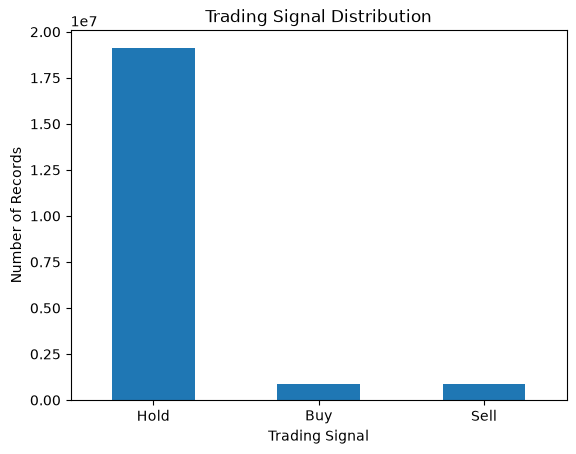

In [18]:
#visualize this in a barchat
signal_counts = df['trading_signal'].value_counts()

signal_counts.plot(kind='bar')

plt.title('Trading Signal Distribution')
plt.xlabel('Trading Signal')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

The majority of observations were classified as HOLD because the MACD and signal line do not cross frequently. BUY and SELL signals occur only when a crossover takes place, while all other observations remain HOLD.

**Calculate the Relative Strength index (RSI) This will provide information on how the prices are moving downward or upward. Note that RSI is usually between 0 and 100**

In [19]:
df = df.sort_values(['ticker', 'date'])

df['price_difference']=(
    df.groupby('ticker')['close'].diff()
)

df['gain'] = df['price_difference'].clip(lower=0)
df['loss'] = -df['price_difference'].clip(upper=0)


In [20]:
#verify the column
print(
    df[['ticker', 'date', 'close',
        'price_difference', 'gain', 'loss']].head(20)
)

   ticker        date      close  price_difference      gain      loss
20      A  1999-12-17  32.859444               NaN       NaN       NaN
21      A  1999-12-20  33.530045          0.670601  0.670601 -0.000000
22      A  1999-12-21  33.351215         -0.178829  0.000000  0.178829
23      A  1999-12-22  34.021816          0.670601  0.670601 -0.000000
24      A  1999-12-23  35.586552          1.564735  1.564735 -0.000000
25      A  1999-12-27  37.777184          2.190632  2.190632 -0.000000
26      A  1999-12-28  43.991417          6.214233  6.214233 -0.000000
27      A  1999-12-29  51.502148          7.510731  7.510731 -0.000000
28      A  1999-12-30  56.688126          5.185978  5.185978 -0.000000
29      A  1999-12-31  55.302216         -1.385910  0.000000  1.385910
30      A  2000-01-03  51.502148         -3.800068  0.000000  3.800068
31      A  2000-01-04  47.567955         -3.934193  0.000000  3.934193
32      A  2000-01-05  44.617310         -2.950645  0.000000  2.950645
33    

In [21]:
#calculate the exponential average value of gain and loss
ave_gain = (
    df.groupby('ticker')['gain']
    .transform(lambda x: x.ewm(span=14, adjust=False).mean())
)

ave_loss = (
     df.groupby('ticker')['loss']
    .transform(lambda x: x.ewm(span=14, adjust=False).mean())
)

In [22]:
rs = ave_gain / ave_loss

In [23]:
df['rsi']= 100-(100/ (1 + rs))

In [24]:
# generate the RSI signals
df['rsi_signal'] = 'Hold'

df.loc[df['rsi'] < 30, 'rsi_signal'] = 'Buy'
df.loc[df['rsi'] > 70, 'rsi_signal'] = 'Sell'

The above code means that 
When RSI < 30 implies you Buy 
When RSI > 70 implies you Sell
any other condition you Hold

*** Create a combined signal for both MACD and RSI

In [25]:
#Create the Combined Trading Signal
df['final_trading_signal'] = 'Hold'

buy_condition= (
    (df['trading_signal'] == 'Buy') &
    (df['rsi_signal'] == 'Buy')
)

sell_condition= (
    (df['trading_signal'] == 'Sell') &
    (df['rsi_signal'] == 'Sell')
)

df.loc[buy_condition, 'final_trading_signal'] = 'Buy'
df.loc[sell_condition, 'final_trading_signal'] = 'Sell'    

In [26]:
#print the final columns
print(
    df[
        ['ticker', 'date', 'rsi', 'macd', 'trading_signal', 'rsi_signal', 'final_trading_signal']
    ].head(60)
)

   ticker        date         rsi       macd trading_signal rsi_signal  \
20      A  1999-12-17         NaN   0.000000           Hold       Hold   
21      A  1999-12-20  100.000000   0.053495            Buy       Sell   
22      A  1999-12-21   96.059065   0.080532           Hold       Sell   
23      A  1999-12-22   96.633173   0.154293           Hold       Sell   
24      A  1999-12-23   97.581668   0.335146           Hold       Sell   
25      A  1999-12-27   98.338011   0.647772           Hold       Sell   
26      A  1999-12-28   99.178734   1.381047           Hold       Sell   
27      A  1999-12-29   99.518447   2.538959           Hold       Sell   
28      A  1999-12-30   99.637808   3.830917           Hold       Sell   
29      A  1999-12-31   92.563093   4.688921           Hold       Sell   
30      A  2000-01-03   75.583859   5.004571           Hold       Sell   
31      A  2000-01-04   61.998437   4.881005           Hold       Hold   
32      A  2000-01-05   53.653028   4.

In [27]:
#verify how many hold, buy and sell
print("Buy:", (df['final_trading_signal'] == 'Buy').sum())
print("Sell:", (df['final_trading_signal'] == 'Sell').sum())
print("Hold:", (df['final_trading_signal'] == 'Hold').sum())

Buy: 7075
Sell: 7435
Hold: 20845824


In [28]:
#express the signal as a percentage
signal_counts = df['final_trading_signal'].value_counts()

signal_percent = (
    df['final_trading_signal']
    .value_counts(normalize=True) * 100
)

print("Counts:")
print(signal_counts)

print("\nPercentages:")
print(signal_percent)

Counts:
final_trading_signal
Hold    20845824
Sell        7435
Buy         7075
Name: count, dtype: int64

Percentages:
final_trading_signal
Hold    99.930442
Sell     0.035642
Buy      0.033916
Name: proportion, dtype: float64


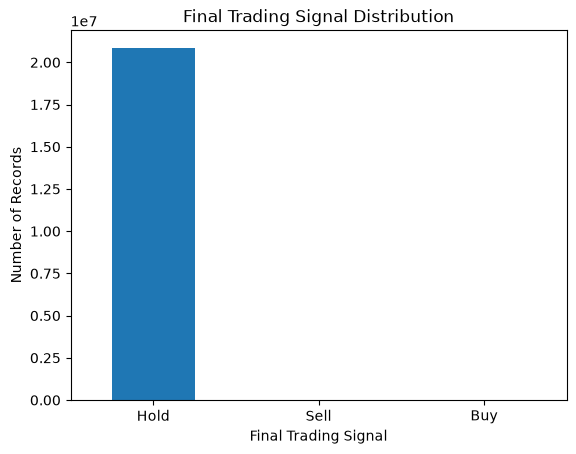

In [29]:
#visualize this in a barchat
signal_counts = df['final_trading_signal'].value_counts()

signal_counts.plot(kind='bar')

plt.title('Final Trading Signal Distribution')
plt.xlabel('Final Trading Signal')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

This shows a high imbalance in the dataset i will verify the signals separately

In [30]:
#for MACD signal
print(df['trading_signal'].value_counts())

trading_signal
Hold    19117954
Buy       871520
Sell      870860
Name: count, dtype: int64


In [31]:
#for RSI signal
print(df['rsi_signal'].value_counts())

rsi_signal
Hold    16051721
Sell     2696316
Buy      2112297
Name: count, dtype: int64


There exist some buy and sell as well as hold under the separate signal. but when it comes to the final trading signal where we are comparing MACS and RSI, the question is, is a buy in MACD occuring thesame time as a Buy in RSI? if it is yes then a buy signal will be recorded. Likewise is a sell happening thesame time in both signals then a sell will be recorded. otherwise a hold. 

In [32]:
#verify the combination
print(
    pd.crosstab(
        df['trading_signal'],
        df['rsi_signal']
    )
)

rsi_signal          Buy      Hold     Sell
trading_signal                            
Buy                7075    729093   135352
Hold            2013802  14550623  2553529
Sell              91420    772005     7435


In [33]:
print("MACD Buy + RSI Buy:",
      ((df['trading_signal'] == 'Buy') &
       (df['rsi_signal'] == 'Buy')).sum())

print("MACD Sell + RSI Sell:",
      ((df['trading_signal'] == 'Sell') &
       (df['rsi_signal'] == 'Sell')).sum())

MACD Buy + RSI Buy: 7075
MACD Sell + RSI Sell: 7435


Only 7074 buy and buy exist and 7435 sell and sell exist and  total hodl of 20,845,824. Therefore it is confirmed that there is a high imbalnce in the distribution of buy and sell.

In [34]:
#check the percentage of imbalance that is represented
signal_percent = (
    df['final_trading_signal']
    .value_counts(normalize=True) * 100
)

print(signal_percent)

final_trading_signal
Hold    99.930442
Sell     0.035642
Buy      0.033916
Name: proportion, dtype: float64


**Part 2- Preparing the data for machine learning**


Note that i will not be using the MACD and RSI strategy to prepare my data for machine learning. because if i do i will be creating a data leakage where by the data is already imbalance, then the model will be learning from the strategies that generate the imbalance. Therefore, the masd and rsi will be excluded and i will be using only the rows and columns that are useful for the situation.


In [35]:
# specify the useful columns

useful_features=[
    'daily_return',
    'close_lag_1',
    'ma_5',
    'ma_20',
    'volatility_20',
    'high_low_range'
]

In [36]:
X = df[useful_features]
y = df['final_trading_signal']

In [37]:
#remove incomplete observation such as any NaN created due to lack of historical data
model_df=df.dropna(
    subset=useful_features +['final_trading_signal']
).copy()

print('model dataset:', model_df.shape)


model dataset: (20860334, 39)


In [38]:
# Encode the target variable
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

model_df['target'] = label_encoder.fit_transform(
    model_df['final_trading_signal']
)
print(
    dict(
        zip(
            label_encoder.classes_,
            label_encoder.transform(label_encoder.classes_)
        )
    )
)

{'Buy': np.int64(0), 'Hold': np.int64(1), 'Sell': np.int64(2)}


In [39]:
#check the target
print(model_df['target'].value_counts())

target
1    20845824
2        7435
0        7075
Name: count, dtype: int64


Buy =0 
Hold =1 
sell=2

Note that in the stock market, todays price is soley depended on yestedays price. Therefore, we can not randomely select the data.For time series data, the data must be sorted and selected chronologically to create that situation where by today's price is dependence of yesterdays. 

In [40]:
#sordting chronologically by date
unique_dates= np.sort(model_df['date'].unique())

In [41]:
#split train/test data
split_index=int(len(unique_dates) * 0.80)

train_end_date= unique_dates[split_index]

train_df =model_df[
    model_df['date'] < train_end_date
].copy()

test_df = model_df[
    model_df['date'] >= train_end_date
].copy()


print('Training:',train_df.shape)
print('Testing:', test_df.shape)

print(
    'Training period:',
    train_df['date'].min(),
    'to',
    train_df['date'].max()
)

print(
    'Testing period:',
    test_df['date'].min(),
    'to',
    test_df['date'].max()
)

    

Training: (10692900, 40)
Testing: (10167434, 40)
Training period: 1970-01-30 to 2008-11-28
Testing period: 2008-12-01 to 2018-08-24


In [42]:
# Create X and y for training data
X_train = train_df[useful_features]
y_train = train_df['target']

# Create X and y for testing data
X_test = test_df[useful_features]
y_test = test_df['target']

# Check the shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10692900, 6)
y_train: (10692900,)
X_test: (10167434, 6)
y_test: (10167434,)


In [43]:
#standardize the numerical features using the training data only so that the scaler learns the mean and standard deviation from the training data only
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The test data should be completely unseen, so we use tranform(x_test) instead of fit transform. This is help the model to predict without any prior leakage

In [ ]:
sample_size=min(300_000,len(x_train_scaled))

rng = np.random.RandomState(42)

sample_indices =rng.choice(
    len(x_train_scaled),
    size=sample_size

**Addressing class imblalance**

In [44]:
#verify the imbalance in the training data
print("Training class distribution:")
print(y_train.value_counts())

print("\nTraining class percentages:")
print(y_train.value_counts(normalize=True) * 100)

Training class distribution:
target
1    10685296
0        3960
2        3644
Name: count, dtype: int64

Training class percentages:
target
1    99.928887
0     0.037034
2     0.034079
Name: proportion, dtype: float64


**Building the Three models**


In [45]:
#use class weight to balance the Logistic Regression 
logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)
logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression completed.")

Logistic Regression completed.


In [46]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest completed.")

Random Forest completed.


In [47]:
#Support Vector Machine
# Create a representative sample of the training data because the dataset is too large.

import numpy as np
rng = np.random.RandomState(42)

sample_indices = rng.choice(
    len(X_train_scaled),
    size=10_000,
    replace=False
)

X_svm = X_train_scaled[sample_indices]
y_svm = y_train.iloc[sample_indices]

print("SVM training sample:", X_svm.shape)

print("\nSVM target distribution:")
print(y_svm.value_counts())

SVM training sample: (10000, 6)

SVM target distribution:
target
1    9993
0       4
2       3
Name: count, dtype: int64


In [48]:
#Support Vector Machine
# Create a representative sample of the training data because the dataset is too large.
X_svm, _, y_svm, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=10000,
    stratify=y_train,# this will preserve the proportions of target variable in the SVM
    random_state=42
)

print("SVM training sample:", X_svm.shape)
print("SVM target distribution:")
print(y_svm.value_counts())

SVM training sample: (10000, 6)
SVM target distribution:
target
1    9993
0       4
2       3
Name: count, dtype: int64


**Evaluate the Model**
Note that the test data was complete unseen by the model. therefore the result should be fair

In [50]:
print("===== LOGISTIC REGRESSION =====")

print("Accuracy:",
      accuracy_score(y_test, logistic_predictions))

print("Precision:",
      precision_score(y_test, logistic_predictions,
                      average='weighted',
                      zero_division=0))

print("Recall:",
      recall_score(y_test, logistic_predictions,
                   average='weighted',
                   zero_division=0))

print("F1-score:",
      f1_score(y_test, logistic_predictions,
               average='weighted',
               zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    logistic_predictions,
    zero_division=0
))

===== LOGISTIC REGRESSION =====
Accuracy: 0.12181224879355007
Precision: 0.9990093354779384
Recall: 0.12181224879355007
F1-score: 0.21635569223100895

Confusion Matrix:
[[   1509     171    1435]
 [ 442394 1233441 8484693]
 [      8     215    3568]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.48      0.01      3115
           1       1.00      0.12      0.22  10160528
           2       0.00      0.94      0.00      3791

    accuracy                           0.12  10167434
   macro avg       0.33      0.52      0.07  10167434
weighted avg       1.00      0.12      0.22  10167434



In [51]:
print("===== RANDOM FOREST =====")

print("Accuracy:",
      accuracy_score(y_test, rf_predictions))

print("Precision:",
      precision_score(y_test, rf_predictions,
                      average='weighted',
                      zero_division=0))

print("Recall:",
      recall_score(y_test, rf_predictions,
                   average='weighted',
                   zero_division=0))

print("F1-score:",
      f1_score(y_test, rf_predictions,
               average='weighted',
               zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_predictions,
    zero_division=0
))

===== RANDOM FOREST =====
Accuracy: 0.9993177236262365
Precision: 0.9986420044332499
Recall: 0.9993177236262365
F1-score: 0.9989797497640698

Confusion Matrix:
[[       0     3115        0]
 [      13 10160497       18]
 [       0     3791        0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3115
           1       1.00      1.00      1.00  10160528
           2       0.00      0.00      0.00      3791

    accuracy                           1.00  10167434
   macro avg       0.33      0.33      0.33  10167434
weighted avg       1.00      1.00      1.00  10167434



In [52]:
print("===== SUPPORT VECTOR MACHINE =====")

print("Accuracy:",
      accuracy_score(y_test, svm_predictions))

print("Precision:",
      precision_score(y_test, svm_predictions,
                      average='weighted',
                      zero_division=0))

print("Recall:",
      recall_score(y_test, svm_predictions,
                   average='weighted',
                   zero_division=0))

print("F1-score:",
      f1_score(y_test, svm_predictions,
               average='weighted',
               zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))

print("\nClassification Report:")
print(classification_report(
    y_test,
    svm_predictions,
    zero_division=0
))


===== SUPPORT VECTOR MACHINE =====
Accuracy: 0.002717204753923163
Precision: 0.997451660849204
Recall: 0.002717204753923163
F1-score: 0.004816882796502017

Confusion Matrix:
[[    3038       33       44]
 [10053938    24544    82046]
 [    3733       13       45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.98      0.00      3115
           1       1.00      0.00      0.00  10160528
           2       0.00      0.01      0.00      3791

    accuracy                           0.00  10167434
   macro avg       0.33      0.33      0.00  10167434
weighted avg       1.00      0.00      0.00  10167434



In [ ]:
#train the SVM
svm_model = SVC(
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_svm, y_svm)

svm_predictions = svm_model.predict(X_test_scaled)

print("SVM completed.")